RQ5: How do the tone and framing of German media coverage of governments change during national election periods compared with non-election periods?

Source: tagesschau_zdf_pbs_events.csv

Visualization: Line chart + shaded windows

German records loaded: 13,037
Government articles: 8,726
Outlet
Tagesschau    8504
ZDF            222

Monthly data points — Tagesschau: 25, ZDF: 14


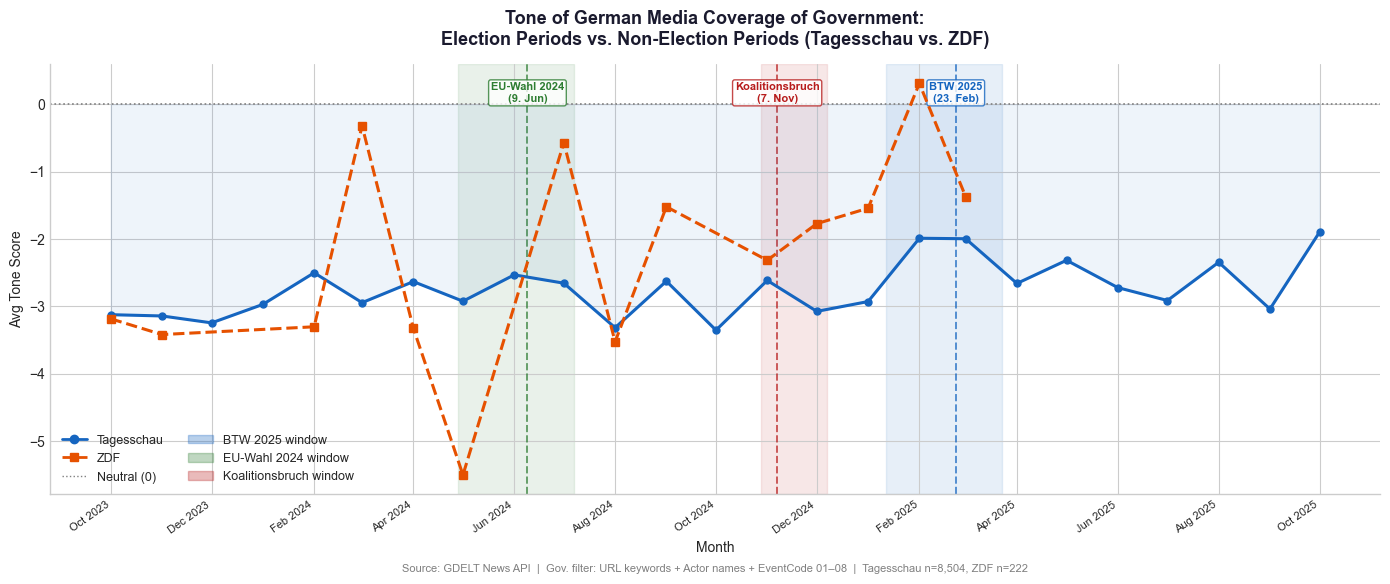

✅ Chart saved as linechart_election_framing.png

── Mean AvgTone: Election vs. Non-Election ──
                                 mean  count    std
Outlet     Period                                  
Tagesschau Election Period     -2.524   2366  2.613
           Non-Election Period -2.831   6138  2.707
ZDF        Election Period     -2.284     34  2.788
           Non-Election Period -3.057    188  2.217


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import os
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ─────────────────────────────────────────────────────────────────────
FOLDER   = r"C:\Users\User\Desktop\DataScienceProjectGroup8"  # ← ANPASSEN
CSV_FILE = "tagesschau_zdf_pbs_events.csv"

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  1. LOAD DATA                                                            ║
# ╚══════════════════════════════════════════════════════════════════════════╝

df = pd.read_csv(os.path.join(FOLDER, CSV_FILE), dtype={'EventCode': str},
                 on_bad_lines='skip')
df.columns = ['SQLDATE','SOURCEURL','AvgTone','NumArticles',
              'Actor1Name','Actor2Name','EventCode']
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d', errors='coerce')

def label_outlet(url):
    if 'tagesschau.de' in str(url): return 'Tagesschau'
    elif 'zdf.de'       in str(url): return 'ZDF'
    else:                            return 'Other'

df['Outlet'] = df['SOURCEURL'].apply(label_outlet)
df_de = df[df['Outlet'].isin(['Tagesschau','ZDF'])].copy()

print(f"German records loaded: {len(df_de):,}")

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  2. GOVERNMENT FILTER                                                    ║
# ║  Only articles PRIMARILY about government / politics                     ║
# ║  → URL keywords + Actor names + EventCode 01–08                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝

GOV_URL_KEYWORDS = [
    'regierung', 'bundestag', 'kanzler', 'minister', 'scholz',
    'ampel', 'koalition', 'bundesregierung', 'spd', 'cdu', 'gruene', 'fdp',
    'bundesrat', 'merz', 'habeck', 'baerbock', 'lindner'
]
GOV_ACTORS = [
    'GOVERNMENT', 'CHANCELLOR', 'MINISTER', 'PARLIAMENT',
    'POLITICIAN', 'PRESIDENT', 'PRIME MINISTER', 'BUNDESRAT'
]

url_filter   = df_de['SOURCEURL'].str.lower().str.contains(
                   '|'.join(GOV_URL_KEYWORDS), na=False)
actor_filter = (
    df_de['Actor1Name'].str.upper().str.contains('|'.join(GOV_ACTORS), na=False) |
    df_de['Actor2Name'].str.upper().str.contains('|'.join(GOV_ACTORS), na=False)
)
code_filter  = df_de['EventCode'].astype(str).str.match(r'^0[1-8]')

df_gov = df_de[url_filter | actor_filter | code_filter].copy()

print(f"Government articles: {len(df_gov):,}")
print(df_gov.groupby('Outlet').size().to_string())

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  3. MONTHLY AGGREGATION                                                  ║
# ╚══════════════════════════════════════════════════════════════════════════╝

df_gov['YearMonth'] = df_gov['SQLDATE'].dt.to_period('M')

monthly = (df_gov.groupby(['Outlet','YearMonth'])['AvgTone']
           .agg(['mean','count']).reset_index())
monthly.columns = ['Outlet','YearMonth','AvgTone','Count']
monthly['Date']  = monthly['YearMonth'].dt.to_timestamp()
monthly = monthly[monthly['Count'] >= 3]   # min 3 articles per month

ts  = monthly[monthly['Outlet']=='Tagesschau'].sort_values('Date')
zdf = monthly[monthly['Outlet']=='ZDF'].sort_values('Date')

print(f"\nMonthly data points — Tagesschau: {len(ts)}, ZDF: {len(zdf)}")

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  4. ELECTION / KEY EVENT WINDOWS                                         ║
# ║  Pre-election = 6 weeks before | Post-election = 4 weeks after           ║
# ╚══════════════════════════════════════════════════════════════════════════╝

EVENTS = [
    {
        "label"     : "BTW 2025\n(23. Feb)",
        "election"  : pd.Timestamp("2025-02-23"),
        "pre_start" : pd.Timestamp("2025-01-12"),
        "post_end"  : pd.Timestamp("2025-03-23"),
        "color"     : "#1565C0",
        "alpha"     : 0.10,
    },
    {
        "label"     : "EU-Wahl 2024\n(9. Jun)",
        "election"  : pd.Timestamp("2024-06-09"),
        "pre_start" : pd.Timestamp("2024-04-28"),
        "post_end"  : pd.Timestamp("2024-07-07"),
        "color"     : "#2E7D32",
        "alpha"     : 0.10,
    },
    {
        "label"     : "Koalitionsbruch\n(7. Nov)",
        "election"  : pd.Timestamp("2024-11-07"),
        "pre_start" : pd.Timestamp("2024-10-28"),
        "post_end"  : pd.Timestamp("2024-12-07"),
        "color"     : "#B71C1C",
        "alpha"     : 0.10,
    },
]

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  5. LINE CHART + SHADED WINDOWS                                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')

# ── Shaded election windows ────────────────────────────────────────────────────
y_top = monthly['AvgTone'].max() + 0.3
for ev in EVENTS:
    ax.axvspan(ev["pre_start"], ev["post_end"],
               color=ev["color"], alpha=ev["alpha"], zorder=0)
    ax.axvline(ev["election"], color=ev["color"],
               linestyle='--', linewidth=1.4, alpha=0.7, zorder=1)
    ax.text(ev["election"], y_top - 0.6, ev["label"],
            ha='center', va='bottom', fontsize=8,
            color=ev["color"], fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor=ev["color"], alpha=0.8))

# ── Tagesschau line ────────────────────────────────────────────────────────────
ax.plot(ts['Date'], ts['AvgTone'], color='#1565C0', linewidth=2.2,
        marker='o', markersize=5, label='Tagesschau', zorder=3)
ax.fill_between(ts['Date'], ts['AvgTone'], alpha=0.07, color='#1565C0', zorder=2)

# ── ZDF line ───────────────────────────────────────────────────────────────────
ax.plot(zdf['Date'], zdf['AvgTone'], color='#E65100', linewidth=2.2,
        marker='s', markersize=6, linestyle='--', label='ZDF', zorder=3)

# ── Neutral reference line ─────────────────────────────────────────────────────
ax.axhline(0, color='gray', linestyle=':', linewidth=1.2)

# ── Axes & formatting ──────────────────────────────────────────────────────────
ax.set_title(
    "Tone of German Media Coverage of Government:\n"
    "Election Periods vs. Non-Election Periods (Tagesschau vs. ZDF)",
    fontsize=13, fontweight='bold', pad=14, color='#1a1a2e'
)
ax.set_xlabel("Month", fontsize=10)
ax.set_ylabel("Avg Tone Score", fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=35, ha='right', fontsize=8)
for s in ['top','right']: ax.spines[s].set_visible(False)

# ── Legend ─────────────────────────────────────────────────────────────────────
outlet_handles = [
    plt.Line2D([0],[0], color='#1565C0', linewidth=2, marker='o', label='Tagesschau'),
    plt.Line2D([0],[0], color='#E65100', linewidth=2, marker='s',
               linestyle='--', label='ZDF'),
    plt.Line2D([0],[0], color='gray', linewidth=1,
               linestyle=':', label='Neutral (0)'),
]
shade_handles = [
    mpatches.Patch(color='#1565C0', alpha=0.3, label='BTW 2025 window'),
    mpatches.Patch(color='#2E7D32', alpha=0.3, label='EU-Wahl 2024 window'),
    mpatches.Patch(color='#B71C1C', alpha=0.3, label='Koalitionsbruch window'),
]
ax.legend(handles=outlet_handles + shade_handles,
          fontsize=9, framealpha=0.9, loc='lower left', ncol=2)

# ── Source note ────────────────────────────────────────────────────────────────
n_ts  = len(df_gov[df_gov['Outlet']=='Tagesschau'])
n_zdf = len(df_gov[df_gov['Outlet']=='ZDF'])
ax.text(0.5, -0.18,
        f"Source: GDELT News API  |  "
        f"Gov. filter: URL keywords + Actor names + EventCode 01–08  |  "
        f"Tagesschau n={n_ts:,}, ZDF n={n_zdf:,}",
        transform=ax.transAxes, ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig("linechart_election_framing.png", dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Chart saved as linechart_election_framing.png")

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  6. STATISTICAL SUMMARY                                                  ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def get_period_label(date):
    for ev in EVENTS:
        if ev["pre_start"] <= date <= ev["post_end"]:
            return "Election Period"
    return "Non-Election Period"

df_gov['Period'] = df_gov['SQLDATE'].apply(get_period_label)

print("\n── Mean AvgTone: Election vs. Non-Election ──")
summary = (df_gov.groupby(['Outlet','Period'])['AvgTone']
           .agg(['mean','count','std']).round(3))
print(summary.to_string())


Interpretation of German Media Tone Around Key Political Events

General pattern:
Both Tagesschau (blue) and ZDF (orange) run consistently below the neutral zero line throughout the entire observation window, confirming a persistently negative tone toward government-related actors across all periods.

Around the EU-Wahl 2024 (June 2024):
Tagesschau shows little visible change in the green shaded area — the line remains relatively flat and stable around its usual range. ZDF is largely absent from this window, making a comparison difficult.

Around the Koalitionsbruch (November 2024):
This is the most visually striking feature of the chart. ZDF's orange line drops sharply downward inside the red window, reaching its lowest point in the entire observation period. Tagesschau also dips slightly but remains comparatively stable. This confirms that the coalition collapse is the single most impactful event on tone visible in the chart.

Around the Bundestagswahl 2025 (February 2025):
Both lines show a visible upward movement inside the blue shaded window, moving closer to the neutral zero line compared to the preceding months. This is the most apparent moderation of tone in the chart for Tagesschau. ZDF's line also rises noticeably, briefly approaching zero meaning neutral tone.

Post-election:
After the blue window closes, both lines trend slightly downward again, though they remain visually higher than the deep dip observed during the Koalitionsbruch period.

Summary:
The chart clearly shows that tone moderation around the Bundestagswahl 2025 is real and visible — both lines climb toward zero inside the blue shading. The Koalitionsbruch window stands out as the sharpest negative spike in the entire chart, suggesting that political crisis drives negativity more forcefully than electoral cycles. Outside of these three windows, Tagesschau's tone is visually very stable, while ZDF's line is considerably more volatile. These findings should however be interpreted with caution given the considerable imbalance in sample size between Tagesschau (n = 12,726) and ZDF (n = 311), which limits the comparability of outlet-level conclusions.